In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("bengaluru_house_prices.csv")
df.head(7)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df = df.drop(columns=['society'])

df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['availability'] = df['availability'].fillna('Ready To Move')


In [6]:
df['bhk'] = df['size'].str.extract('(\d+)').astype(float)
df = df.drop(columns=['size'])
df['bhk'] = df['bhk'].fillna(df['bhk'].median())


In [7]:
df.head()
df.shape

(13320, 8)

In [8]:
df['location'] = df['location'].str.strip()

top_locations = df['location'].value_counts().nlargest(30).index
df['location'] = df['location'].apply(lambda x: x if x in top_locations else 'other')


df['is_ready'] = (df['availability'].str.strip() == 'Ready To Move').astype(int)
df = df.drop(columns=['availability'])


In [9]:
def convert_sqft(x):
    x = str(x).strip()
    if '-' in x:
        a, b = x.split('-')
        return (float(a) + float(b)) / 2
    try:
        return float(x.split()[0])
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])


In [10]:
def remove_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outlier(df, 'price')
df = remove_outlier(df, 'total_sqft')

In [11]:

# ================= REMOVE OUTLIERS =================
df = df[(df['price'] > 0)]

df = df[(df['total_sqft']/df['bhk'] < 1000)]
df = df[(df['total_sqft']/df['bhk'] > 300)]

# ================= PRICE PER SQFT FILTER =================
df['pps'] = df['price'] / df['total_sqft']
lower = df['pps'].quantile(0.05)
upper = df['pps'].quantile(0.95)

df = df[(df['pps'] > lower) & (df['pps'] < upper)]
df = df.drop('pps', axis=1)


In [12]:
df.describe()

,total_sqft,bath,balcony,price,bhk,is_ready
count,9406.000000,9406.000000,9406.000000,9406.000000,9406.000000,9406.000000
mean,1300.752307,2.265150,1.595046,69.432615,2.400808,0.788220
std,334.954800,0.615303,0.765034,29.627823,0.626115,0.408591
min,375.000000,1.000000,0.000000,14.000000,1.000000,0.000000
25%,1100.000000,2.000000,1.000000,48.000000,2.000000,1.000000
50%,1246.000000,2.000000,2.000000,62.390000,2.000000,1.000000
75%,1500.000000,3.000000,2.000000,85.000000,3.000000,1.000000
max,2254.000000,6.000000,3.000000,200.000000,6.000000,1.000000


In [13]:
df.head()


,area_type,location,total_sqft,bath,balcony,price,bhk,is_ready
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,1
3,Super built-up Area,other,1521.0,3.0,1.0,95.00,3.0,1
4,Super built-up Area,other,1200.0,2.0,1.0,51.00,2.0,1
5,Super built-up Area,Whitefield,1170.0,2.0,1.0,38.00,2.0,1


In [14]:

# ================= FEATURES =================
X = df[['total_sqft', 'bath', 'balcony', 'bhk', 'is_ready', 'location', 'area_type']]

X = pd.get_dummies(X, columns=['location', 'area_type'])

y = df['price']  


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))


Linear Regression
R2: 0.6560785109497898
MAE: 13.253746833689949


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))



Random Forest
R2: 0.7051607817437437
MAE: 11.603865099502638


In [17]:

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("\nXGBoost")
print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))



XGBoost
R2: 0.6934590254607677
MAE: 11.509816503129526


In [18]:

results = pd.DataFrame({
    "Model": ["Linear", "RandomForest", "XGBoost"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ]
})

print("\nModel Comparison:\n", results)



Model Comparison:
           Model        R2        MAE
0        Linear  0.656079  13.253747
1  RandomForest  0.705161  11.603865
2       XGBoost  0.693459  11.509817


In [19]:
final_pred = (0.7 * rf_pred) + (0.3 * xgb_pred)
print("Ensemble R2:", r2_score(y_test, final_pred))

Ensemble R2: 0.7068679809906333


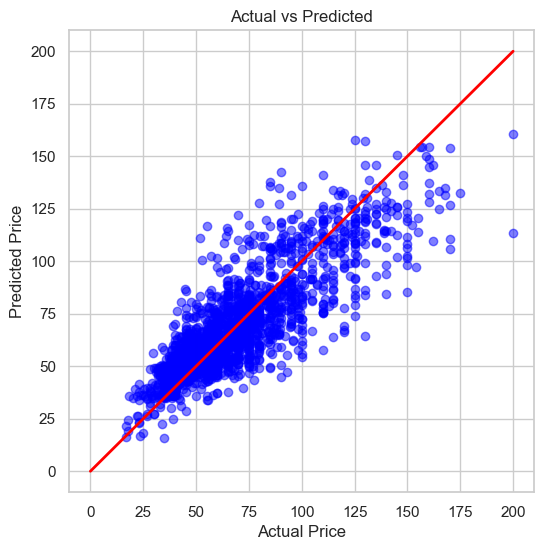

In [20]:
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred, color='blue', alpha=0.5)

line = [0, max(y_test)]
plt.plot(line, line, color='red', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

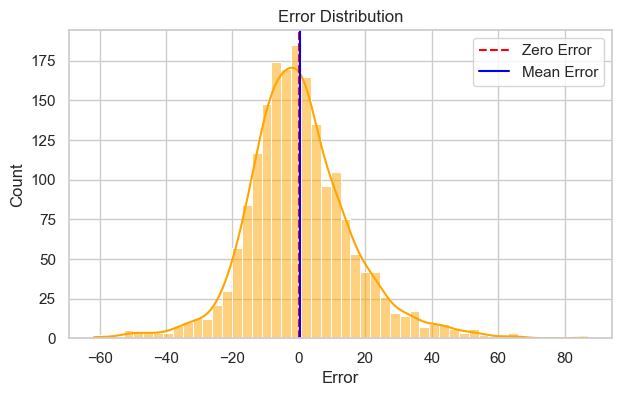

In [21]:
import seaborn as sns
sns.set(style="whitegrid")

errors = y_test - rf_pred

plt.figure(figsize=(7,4))
sns.histplot(errors, bins=50, kde=True, color="orange")

plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.axvline(errors.mean(), color='blue', linestyle='-', label='Mean Error')

plt.legend()
plt.title("Error Distribution")
plt.xlabel("Error")
plt.show()

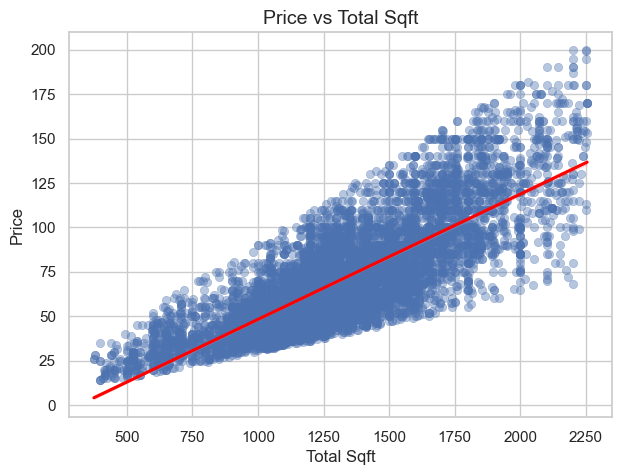

In [22]:
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['total_sqft'],
    y=df['price'],
    alpha=0.4,
    edgecolor=None
)
sns.regplot(
    x=df['total_sqft'],
    y=df['price'],
    scatter=False,
    color='red'
)

plt.title("Price vs Total Sqft", fontsize=14)
plt.xlabel("Total Sqft")
plt.ylabel("Price")

plt.show()

In [24]:
df.to_excel("house_prediction.xlsx",index=False)